# Rössler Sensitivity

First we solve the Rössler system and obtain a dense numerical interpolant $\mathbf{y}(t)$ and use that as input to the sensivity computation
$$ \dot J(t)=Df(\mathbf{x}(t))J(t), \qquad J(0)=Id.$$
Julia can interpret the output of tsit5 for
$$\dot x=-y-z, \qquad \dot y=x+ay, \qquad \dot z=b+z(x-c),$$
with $(a,b,c)=(0.2,0.2,5.7)$ as a continuous interpolant. 

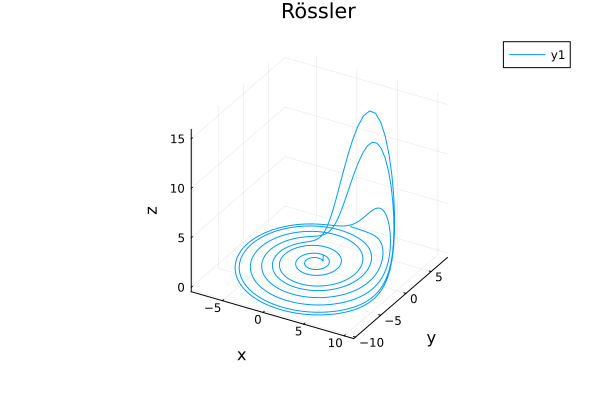

In [156]:
using DifferentialEquations, LinearAlgebra, Plots
function rossler!(du, u, p, t)
    a, b, c = p
    x, y, z = u
    du[1] = -y - z
    du[2] =  x + a*y
    du[3] =  b + z*(x - c)
    return nothing
end
params = (0.2, 0.2, 5.7)
state_initial = [1.0, 0.0, 1.0]
tMax=50.0;
tspan = (0.0, tMax)

state_problem = ODEProblem(rossler!, state_initial, tspan, params)

ySol = solve(
    state_problem,
    Tsit5();
    abstol = 1e-10,
    reltol = 1e-10,
    dense = true
);
tVals =0.0:0.05:tMax
time_plot = plot(
    ySol(tVals);
    xlabel = "t", ylabel = " ",
    title = "Rössler"
)
phase_plot = plot(
    ySol(tVals)[1,:],  ySol(tVals)[2,:], ySol(tVals)[3,:];
    xlabel = "x", ylabel = "y", zlabel="z",
    title = "Rössler"
)

## Sensitivity/Variational ODE

The derivative of the rossler $f$ is 
$$Df((x,y,z))=\begin{pmatrix}0&-1&-1\\1&a&0\\z&0&x-c\end{pmatrix}.$$
Differentiating the original ODE gives a matrix ODE Julia 
that Julia can solve 
$$\dot J(t)=Df(\mathbf{x}(t))J(t) \quad J(0)=Id.$$

Here is a demo.  The big question is what does this mean?

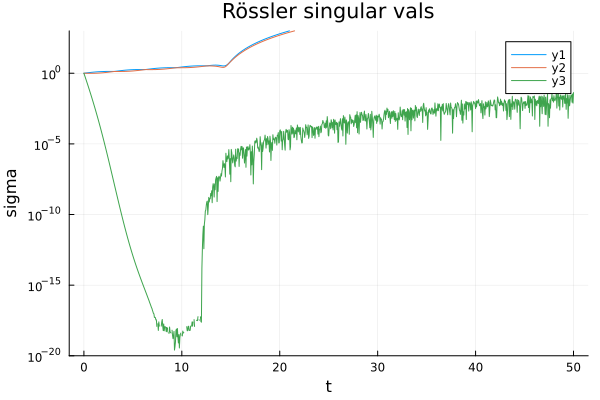

┌ Warning: Invalid negative or zero value 0.0 found at series index 151 for log10 based yscale
└ @ Plots C:\Users\AllanStruthers\.julia\packages\Plots\h49MV\src\utils.jl:105
┌ Warning: Invalid negative or zero value 0.0 found at series index 151 for log10 based yscale
└ @ Plots C:\Users\AllanStruthers\.julia\packages\Plots\h49MV\src\utils.jl:105
┌ Warning: Invalid negative or zero value 0.0 found at series index 151 for log10 based yscale
└ @ Plots C:\Users\AllanStruthers\.julia\packages\Plots\h49MV\src\utils.jl:105


In [159]:
function Df(u, p)
    x, y, z = u
    a, b, c = p
    return [
        0.0  -1.0  -1.0
        1.0   a     0.0
        z     0.0   x-c
    ]
end

function rosslerJ!(dJ, J, p, t)
    a, b, c = p
    u = ySol(t)
    dJ .= Df(u,p)*J
    return nothing
end
J_initial = [
    1.0 0.0 0.0
    0.0 1.0 0.0
    0.0 0.0 1.0]
tMax=12;
tspan = (0.0, tMax)
J_problem = ODEProblem(rosslerJ!, J_initial, tspan, params)
JSol = solve(
    J_problem,
    Tsit5(),
    abstol = 1e-10,
    reltol = 1e-10,
    dense = true);
function s(t)
    return svdvals(JSol(t))
end
sList=s.(tVals);
sMat = reduce(hcat,sList)';
plot(tVals, sMat,
    xlabel = "t", ylabel = "sigma",
    title = "Rössler singular vals",
    yscale=:log10,
    ylims = (1e-20, 1e3)
)

If you dislike the explict plot range you can clip the data rather than the plot. 

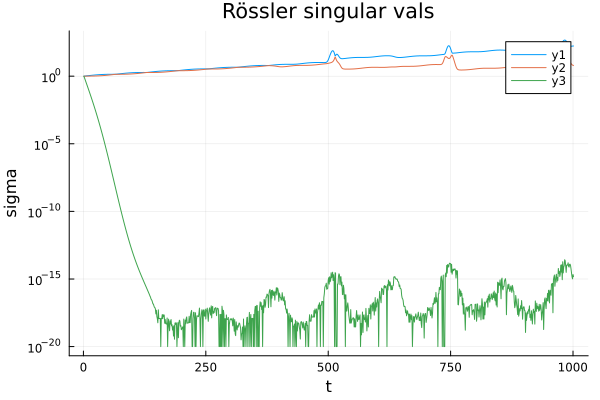

In [150]:
plot(max.(sMat,10^-20),
    xlabel = "t", ylabel = "sigma",
    title = "Rössler singular vals",
    yscale=:log10
)